# 1 · Cómo se evalúa + baselines (IForest, One-Class SVM)

Antes de los modelos profundos, fijamos **cómo se mide** y dos baselines clásicos.

**Métrica principal: PR-AUC** (área Precision-Recall, libre de umbral). Razones:
- El **F1 con umbral fijo engaña**: el umbral se calibra en val (tasa ~6%) pero en test
  la tasa salta a ~27% (sequía 2022/23) → un corte absoluto marca casi todo → F1 ≈ tasa
  base para todos.
- Todo se reporta **multi-seed (media ± std)** porque los modelos profundos varían.

**Política de semillas (para que las comparaciones sean justas):**
- Evaluar **cualquier modelo** = **10 semillas** (`SEEDS`), reportando media ± desvío.
- Los modelos **deterministas** (One-Class SVM) no tienen semilla → std = 0; los
  estocásticos (VAE, AE, DAE, **Isolation Forest**) sí varían y muestran su ±std.
- Los **barridos** (búsqueda de HP en nb 3, ablación de features en nb 6) usan **5
  semillas** — es un screening de muchas configuraciones, se declara donde se hace.

`lab.metrics(scores, y)` devuelve PR-AUC, ROC-AUC, precisión@k y recall al top-10%;
`lab.evaluate(make_detector, ds, seeds)` corre esas semillas y da (media, desvío).

In [1]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


In [2]:
panel_z = data.prepare()                         # panel + etiqueta z_rinde
ds   = data.build_crop_dataset(panel_z, "soja")  # split + normalización (soja)
dsm  = data.build_crop_dataset(panel_z, "maiz")  # idem maíz
print("soja  train:", ds.X_train.shape, "| test anómalas:", int(ds.y_test.sum()))
print("maíz  train:", dsm.X_train.shape, "| test anómalas:", int(dsm.y_test.sum()))

[data] dedup panel: 28683 → 21418 filas (7265 duplicados espurios por lat/lon eliminados)


soja  train: (6377, 54) | test anómalas: 257
maíz  train: (8347, 54) | test anómalas: 349


## 1.1 · Isolation Forest — el baseline
Ensamble de árboles que aísla puntos raros; no neuronal, varianza baja. El único
hiperparámetro con efecto real fue `max_features=0.3` (cada árbol mira un subconjunto de
las 54 features). Lo entrenamos y evaluamos a la vista:

In [3]:
iforest = IsolationForestDetector(n_estimators=200, max_features=0.3).fit(ds.X_train)
scores_if = iforest.score_samples(ds.X_test)      # mayor = más anómalo
lab.metrics(scores_if, ds.y_test)

{'pr_auc': 0.5061872937690888,
 'roc_auc': 0.700662650938709,
 'prec_at_k': 0.4785992217898833,
 'recall_at_contam': 0.2529182879377432}

## 1.2 · One-Class SVM — frontera no lineal
Aprende una frontera que envuelve a los datos normales; lo de afuera es anómalo. Con
**kernel RBF (gaussiano)** la frontera es no lineal. Comparamos RBF vs lineal para ver
que la no-linealidad importa:

In [4]:
for kernel in ["rbf", "linear"]:
    oc = OneClassSVMDetector(kernel=kernel, nu=0.1).fit(ds.X_train)
    m = lab.metrics(oc.score_samples(ds.X_test), ds.y_test)
    print(f"OCSVM {kernel:7s}  PR-AUC={m['pr_auc']:.3f}  ROC={m['roc_auc']:.3f}")

OCSVM rbf      PR-AUC=0.477  ROC=0.706


OCSVM linear   PR-AUC=0.233  ROC=0.374


**El kernel lineal fracasa** y el **RBF (gaussiano) es competitivo con el IForest**
(comparar los PR-AUC impresos arriba). La frontera no lineal es imprescindible.

## 1.3 · El umbral no transfiere entre períodos (distribution shift)
El PR-AUC mide el *ranking* y es libre de umbral. Pero para una matriz de confusión hace
falta un **corte**, y un umbral absoluto no transfiere entre períodos: los scores se corren
hacia arriba entre el período de entrenamiento y el de test (2021–24) → un corte fijo marca
~70% del test. Por eso re-umbralizamos sobre los scores del **propio test** en dos puntos:
top-10% (presupuesto de alertas) y top-tasa real (~27%).

IForest {'precision': np.float64(0.688), 'recall': np.float64(0.257), 'tp': np.int64(66), 'fp': np.int64(30), 'fn': np.int64(191), 'tn': np.int64(667)}
IForest {'precision': np.float64(0.479), 'recall': np.float64(0.479), 'tp': np.int64(123), 'fp': np.int64(134), 'fn': np.int64(134), 'tn': np.int64(563)}


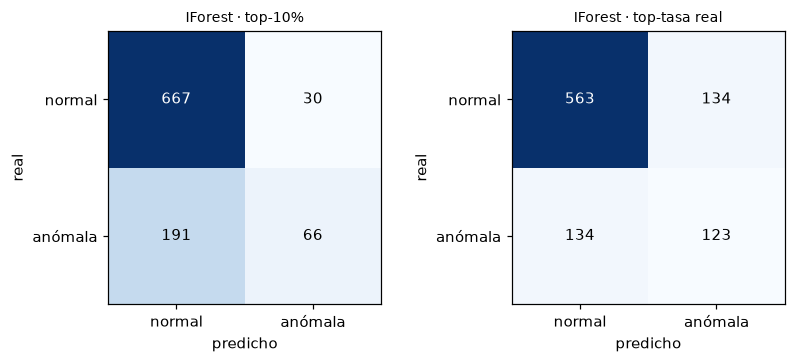

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(7.5, 3.4))
for ax, q in zip(axs, [0.10, "base"]):
    print("IForest", lab.confusion_top(scores_if, ds.y_test, q, ax=ax, titulo="IForest"))
plt.tight_layout(); plt.show()

## 1.4 · Por qué no hay validación (y por qué comparamos en test)
El diseño clásico separa un set de validación para seleccionar modelos/hiperparámetros. Acá
**no lo usamos**, por una razón concreta: probamos con un val 2018–2020 y resultó **ciego**.
Sus anomalías son de años **sin sequía grande** → sin firma climática (justo las del techo
estructural, nb 5) → el PR-AUC en ese val daba **≈ la tasa base (azar), igual para todos los
modelos**. No discriminaba nada: seleccionar ahí habría sido tirar una moneda.

Dos consecuencias:
1. **El val se pliega al train** → 3 años más de campañas normales, y el train queda más
   cerca del clima de test.
2. **Las comparaciones y la selección de HP (nb 3) se ilustran en test**, con el *data
   snooping* declarado como limitación. La confianza en el modelo final no viene del número
   puntual sino de la **consistencia entre cultivos** y la **varianza mínima entre semillas**.

**Baseline a superar: el Isolation Forest de arriba** (su PR-AUC es el listón).
En los próximos notebooks intentamos superarlo con modelos de reconstrucción.